In [19]:
# Colby Wirth
# COS 472 Assignment 1 
# September 24 2024

#import libraries needed
#Read .csv file and create a df for the djia

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from datetime import datetime

djia_df = pd.read_csv('HistoricalPrices_2023.csv')

djia_df.head()

,Date,Open,High,Low,Close
0,12/29/23,37701.63,37759.43,37538.80,37689.54
1,12/28/23,37661.52,37778.85,37650.98,37710.10
2,12/27/23,37518.62,37683.70,37488.60,37656.52
3,12/26/23,37405.90,37617.99,37371.83,37545.33
4,12/22/23,37349.27,37534.52,37268.88,37385.97


In [20]:
#Reformat Date to datetime object
#organize by date
#Display first five elements

djia_df['Date'] = pd.to_datetime(djia_df['Date'])
djia_df =djia_df.sort_values(by = 'Date')
djia_df.head()


/var/folders/xk/fhgbj8qj60n54b05mpfnck0w0000gn/T/ipykernel_35315/3994003396.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  djia_df['Date'] = pd.to_datetime(djia_df['Date'])


,Date,Open,High,Low,Close
249,2023-01-03,33148.90,33387.52,32850.57,33136.37
248,2023-01-04,33165.14,33409.10,33033.48,33269.77
247,2023-01-05,33191.72,33191.72,32812.33,32930.08
246,2023-01-06,33055.30,33710.66,32997.39,33630.61
245,2023-01-09,33664.39,33935.11,33487.66,33517.65


In [21]:
#List atrributes

djia_df.columns

Index(['Date', ' Open', ' High', ' Low', ' Close'], dtype='object')

In [22]:
#Labels need to be reconfigured and remove spaces
#And Check my fixes

djia_df = djia_df.rename(columns= {' Open' : 'Open', ' High' : 'High', ' Low' : 'Low', ' Close' : 'Close'})

djia_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

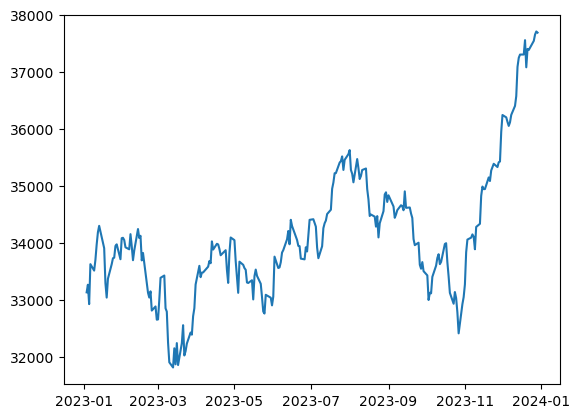

In [23]:
#Plot a Line Plot with Date on x Axis, and Close Price on y Axis

plt.plot(djia_df['Date'], djia_df['Close'])
plt.show()

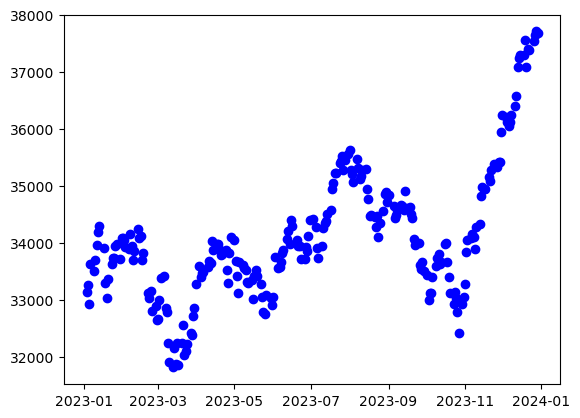

In [24]:
#Reconfigure the graph with a new style
#'b' sets color to blue, 'o' sets style to dots
plt.plot(djia_df['Date'], djia_df['Close'], 'bo')
plt.show()

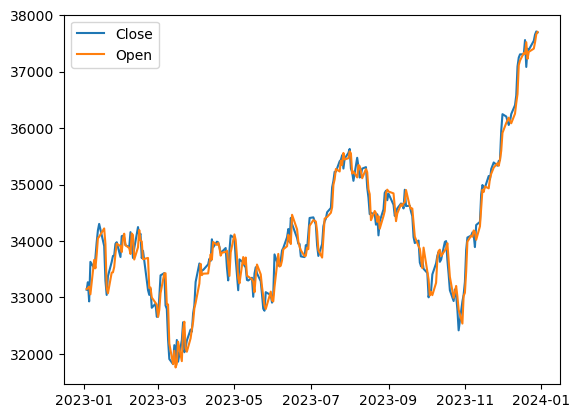

In [25]:
#Open and closed graphed 
#Add legend and labels for clarity

plt.plot(djia_df['Date'], djia_df['Close'], label='Close')
plt.plot(djia_df['Date'], djia_df['Open'], label='Open')

plt.legend()
plt.show()


In [26]:
#Preparing data for bar graphs.  Data must be aggregated into categories.
#Choose to use monthly averages
from calendar import month_name

## Change the categorical data to Ordinal.  Use the calendar library from python
djia_df['Month'] = pd.Categorical(djia_df['Date'].dt.month_name(), month_name[1:])

#Create aggregated data points by each month
djia_monthly_mean = djia_df.groupby('Month').mean().reset_index()

#Display data
djia_monthly_mean

/var/folders/xk/fhgbj8qj60n54b05mpfnck0w0000gn/T/ipykernel_35315/1847339652.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  djia_monthly_mean = djia_df.groupby('Month').mean().reset_index()


,Month,Date,Open,High,Low,Close
0,January,2023-01-16 15:36:00.000000000,33594.735000,33823.690000,33390.498500,33656.000500
1,February,2023-02-14 00:00:00.000000000,33696.416316,33844.902632,33438.562105,33648.256316
2,March,2023-03-16 08:20:52.173913088,32477.036957,32694.497826,32249.975217,32483.478261
3,April,2023-04-15 22:44:12.631578880,33674.288421,33832.691579,33549.615789,33731.280526
4,May,2023-05-15 01:05:27.272727296,33372.439091,33480.161364,33150.101364,33316.802273
5,June,2023-06-15 21:42:51.428571392,33828.082857,34001.955714,33727.557143,33904.976190
6,July,2023-07-16 20:24:00.000000000,34731.967500,34898.006000,34646.135500,34777.200000
7,August,2023-08-16 00:00:00.000000000,34915.545652,35076.850870,34750.499130,34880.656957
8,September,2023-09-16 08:24:00.000000000,34386.032500,34493.456000,34210.815500,34318.891000
9,October,2023-10-15 22:54:32.727272704,33347.390909,33512.733636,33150.617273,33319.492727


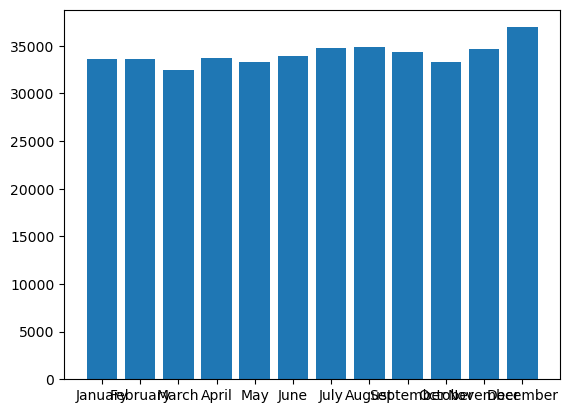

In [27]:
#Display djia is vertical bar plots  
# months on x axis, close price on y

plt.bar(djia_monthly_mean['Month'], height=djia_monthly_mean['Close'])

plt.show()



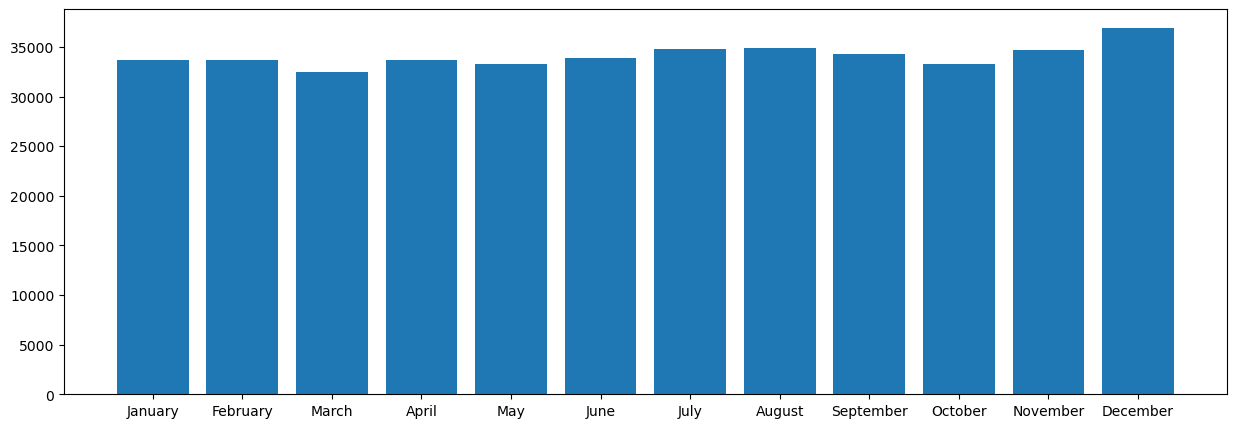

In [28]:
#Readjust width with first number, '15' and height with second '5'
#Labels will now not overlap

#recongire the bar graph and show

plt.figure(figsize=(15,5))
plt.bar(djia_monthly_mean['Month'], height=djia_monthly_mean['Close'])
plt.show()

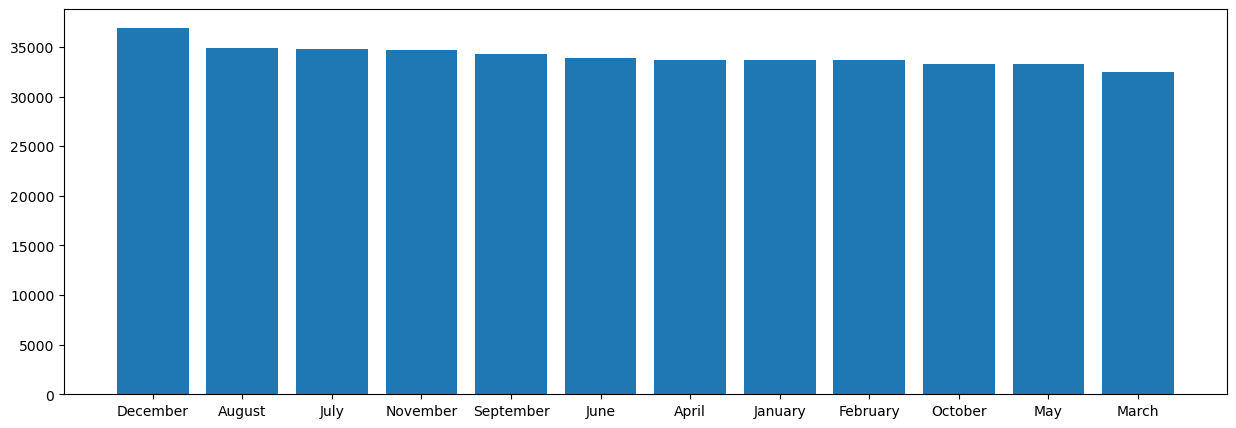

In [29]:
#Reorder graphs in ascending order with sort_values()

djia_monthly_mean_sorted = djia_monthly_mean.sort_values(by = 'Close', ascending=False)

plt.figure(figsize=(15,5))

#Display new values in the plot

plt.bar(djia_monthly_mean_sorted['Month'], height=djia_monthly_mean_sorted['Close'])

plt.show()


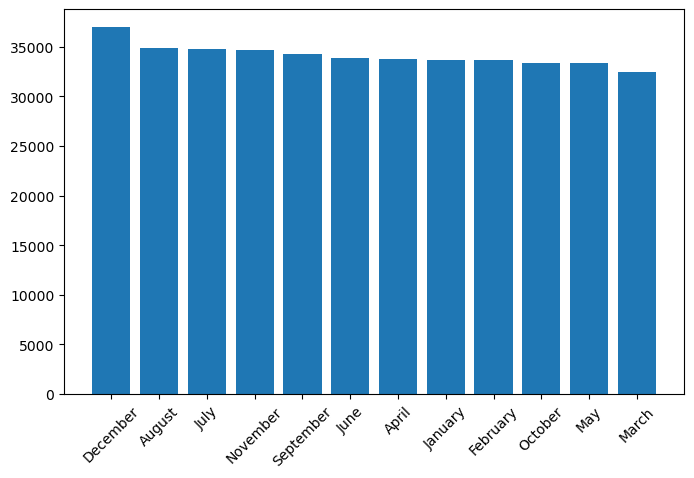

In [30]:
#Rotate x axis by 45 degrees and shrink graph

plt.figure(figsize=(8,5))

plt.bar(djia_monthly_mean_sorted['Month'], height=djia_monthly_mean_sorted['Close'])

plt.xticks(djia_monthly_mean_sorted['Month'], rotation=45)

plt.show()


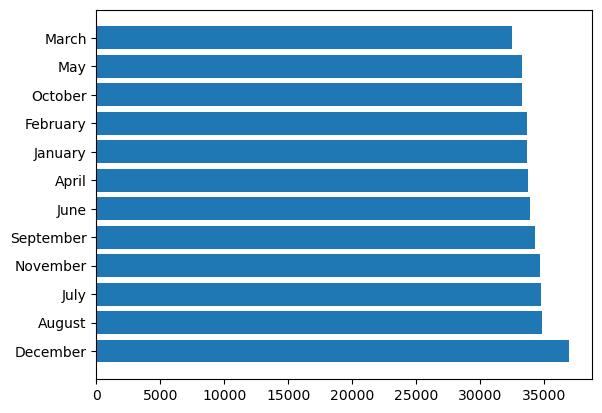

In [31]:
#Display on horizontal graph

plt.barh(djia_monthly_mean_sorted['Month'], djia_monthly_mean_sorted['Close'])

plt.show()


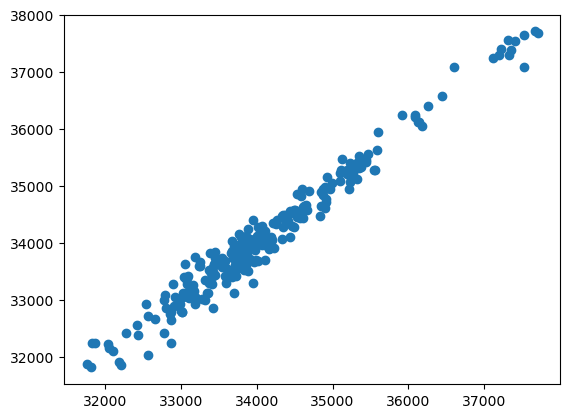

In [32]:
#Display a scatter plot

plt.scatter(djia_df['Open'], djia_df['Close'])

plt.show()

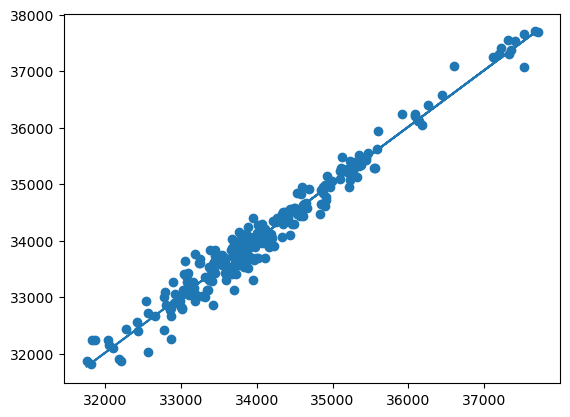

In [33]:
#Apply a trend line to the scatter plot
#numpy module gives access to trendlines

#'1' denotes a 1 degree polynomial
z = np.polyfit(djia_df['Open'], djia_df['Close'], 1)

#this creates the function from 'z'
p = np.poly1d(z)

plt.scatter(djia_df['Open'], djia_df['Close'])
plt.plot(djia_df['Open'], p(djia_df['Open']))

plt.show()


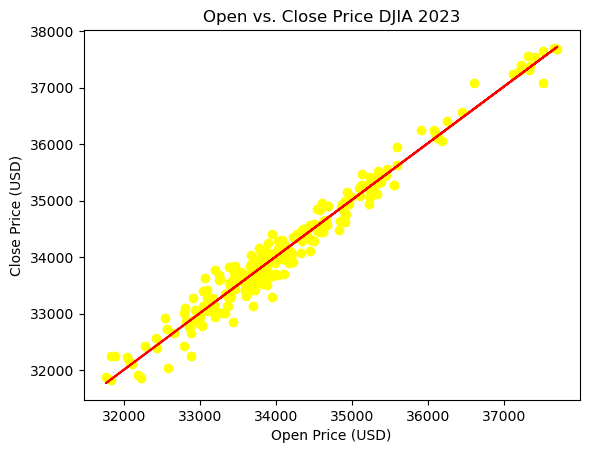

In [34]:
#Change color and add axis labels

z = np.polyfit(djia_df['Open'], djia_df['Close'], 1)
p = np.poly1d(z)

plt.scatter(djia_df['Open'], djia_df['Close'], color = 'yellow')
plt.plot(djia_df['Open'], p(djia_df['Open']), color = 'red')

plt.title("Open vs. Close Price DJIA 2023")
plt.xlabel("Open Price (USD)")
plt.ylabel("Close Price (USD)")


plt.show()

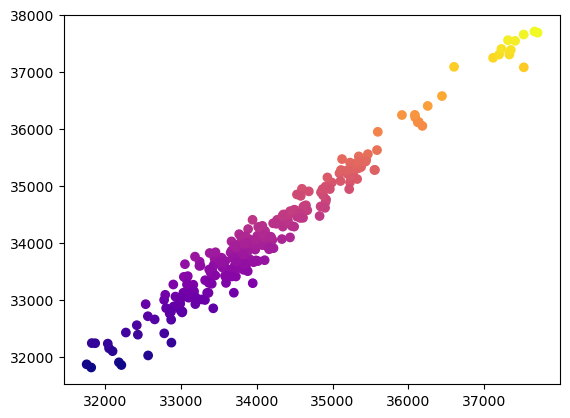

In [35]:
#Color map function with  'cmap'
#Darker color represents higher density, and lighter represents lower debsity

plt.scatter(djia_df['Open'], djia_df['Close'],c=djia_df['Close'], cmap = plt.cm.plasma)


(33000.0, 35000.0)

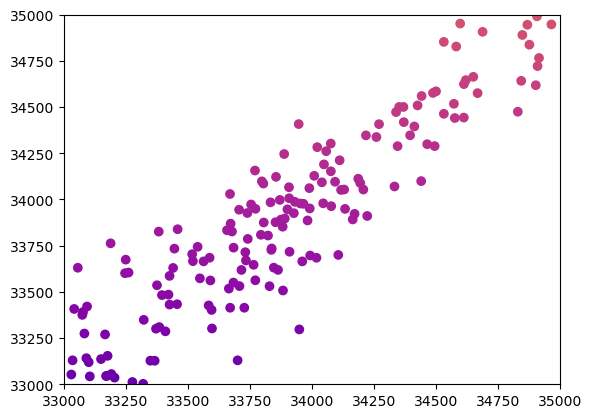

In [36]:
#Adjust axes ranges

plt.scatter(djia_df['Open'], djia_df['Close'],c=djia_df['Close'], cmap = plt.cm.plasma)

plt.xlim(33000,35000)
plt.ylim(33000,35000)

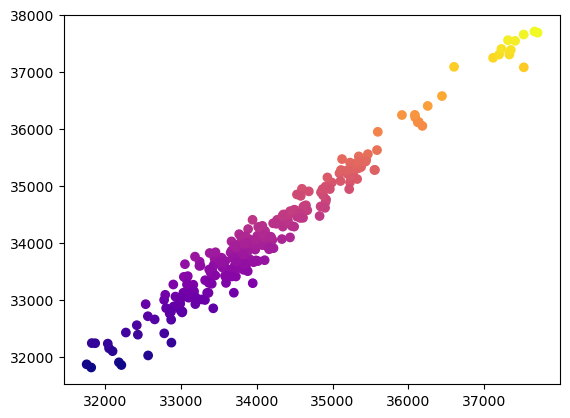

In [37]:
#Saving plot with plot.savefig()

plt.scatter(djia_df['Open'], djia_df['Close'],c=djia_df['Close'], cmap = plt.cm.plasma)

plt.savefig('./Open vs. Close Price DJIA in 2023.png')
plt.show()

In [38]:
#Load tips dataset from Seaborn

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='Count'>

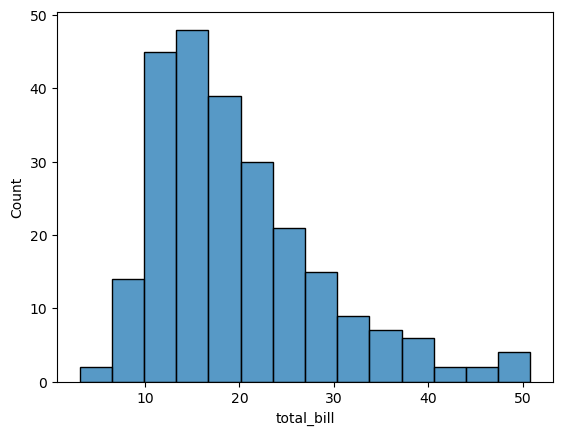

In [39]:
#Histogram with total bull amount on x axis
sns.histplot(data=tips, x="total_bill")

<Axes: xlabel='total_bill', ylabel='Count'>

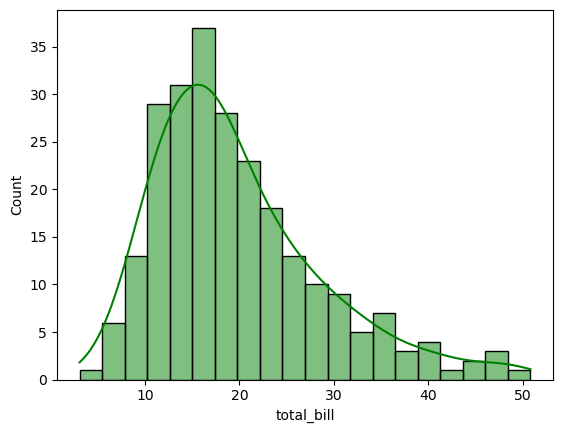

In [40]:
#customize color, kde, and bin amount
#kde vis Kernel Density Estimate -> used to estimate a probabilility density function (continuous data)
sns.histplot(data=tips, x="total_bill", bins=20, kde=True, color="green")

<Axes: xlabel='total_bill', ylabel='tip'>

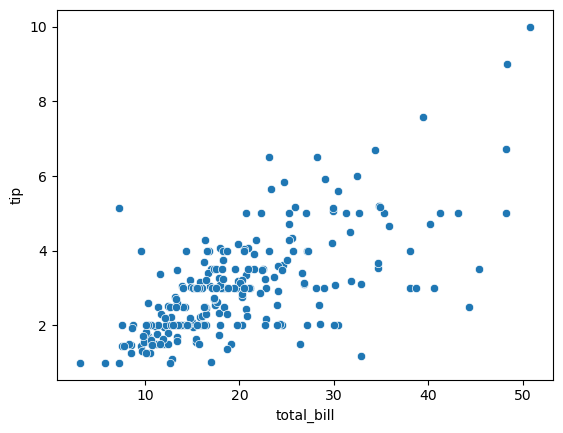

In [41]:
#Scatter plot in Seaborn

sns.scatterplot(data=tips, x='total_bill', y="tip")

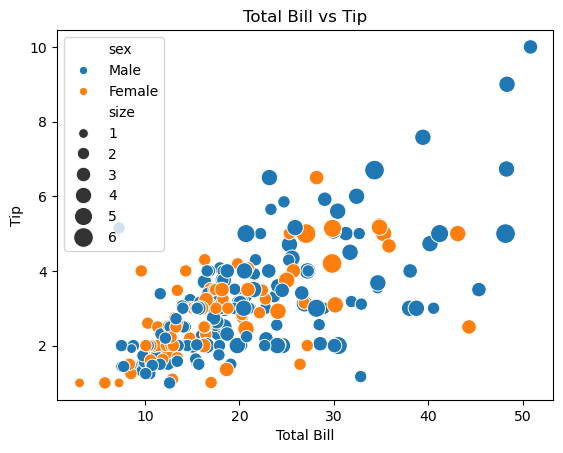

In [43]:
#Chaning size and huge

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", size="size", sizes=(50,200))

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

In [50]:
#Line plot with fmri data set from Seaborn

fmri = sns.load_dataset("fmri")
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


<Axes: xlabel='timepoint', ylabel='signal'>

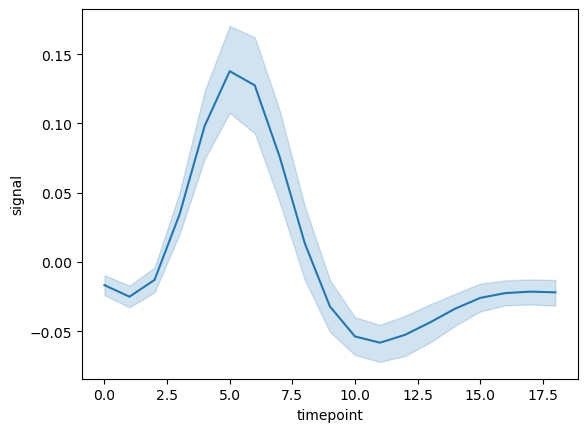

In [51]:
#Basic lineplot with fmri dataset

sns.lineplot(data=fmri, x="timepoint", y="signal")

<Axes: xlabel='timepoint', ylabel='signal'>

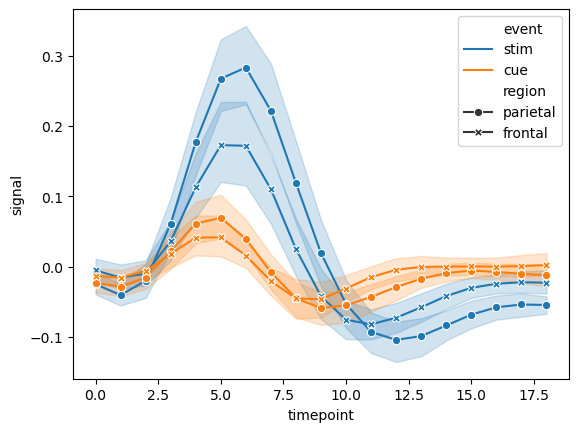

In [52]:
#Hue distinquishes between elements in the 'event' attribute
#Each region gets a unique style

sns.lineplot(data=fmri, x="timepoint", y="signal", hue="event", style="region", markers=True, dashes=False)

In [53]:
#Titanic dataset

titanic=sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='class', ylabel='fare'>

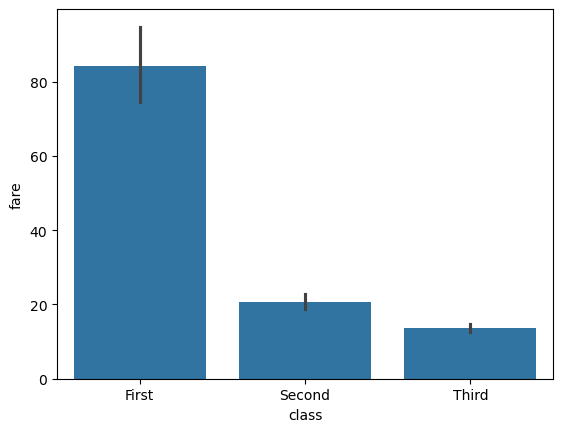

In [54]:
sns.barplot(data=titanic, x="class", y="fare")

<Axes: xlabel='class', ylabel='fare'>

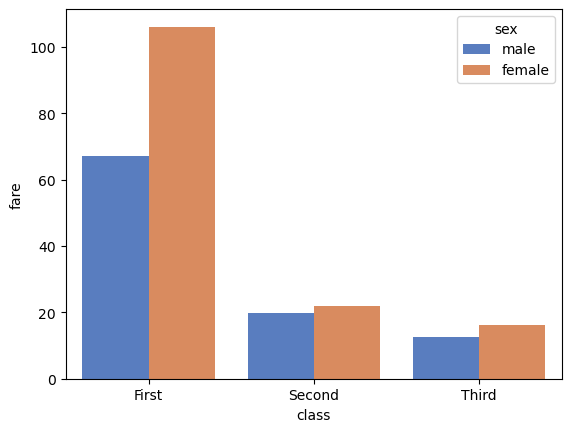

In [55]:
#Distinguish between sexes in the classes with hue

sns.barplot(data=titanic, x="class", y="fare", hue="sex", errorbar=None, palette="muted")

<Axes: xlabel='day', ylabel='total_bill'>

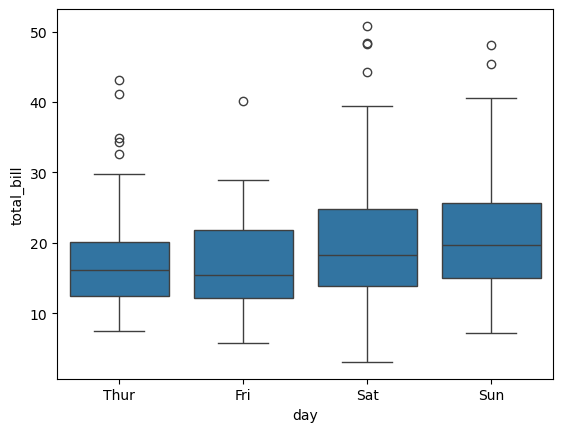

In [56]:
#Create box and whisker plot
#entries outside the whiskers are more than 1.5x IQR

sns.boxplot(data=tips, x="day", y="total_bill")

<Axes: xlabel='day', ylabel='total_bill'>

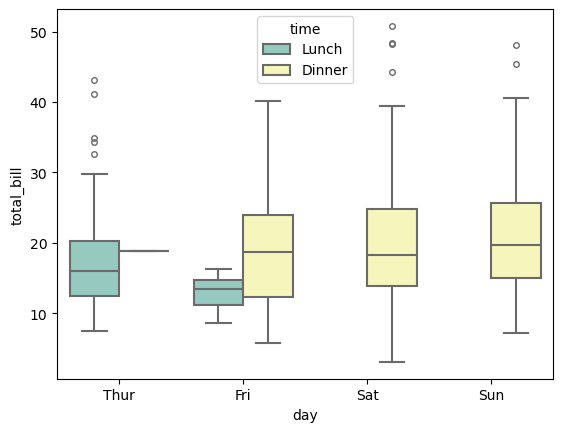

In [57]:
#Use hue to distinguish between linch and dinner within time attribute

#palette  uses Set3 color scheme

sns.boxplot(x="day", y="total_bill", hue="time", data=tips, palette="Set3", linewidth=1.5, fliersize=4)


In [59]:
#load flights dataset
flights=sns.load_dataset('flights')

flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [60]:
#Display flights dataset as a matrix

flights = flights.pivot(index='month', columns='year', values='passengers')

flights

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


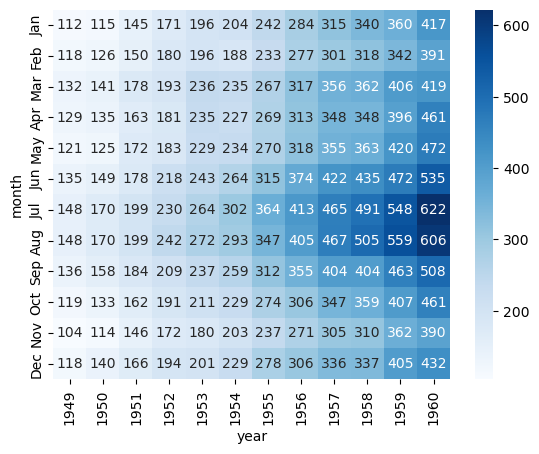

In [61]:
#display a heatmap for flights

sns.heatmap(flights, cmap='Blues', annot=True, fmt='d')

plt.savefig('flights_heatmap.png')